In [1]:
import json
from pathlib import Path

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

from sklearn.metrics import accuracy_score

In [24]:
plt.style.use("../clane.mplstyle")
PLOTW = 3.25  # 6.75 two column width, 0.25 pad
plt.rcParams["figure.dpi"] = 300

In [3]:
paths = sorted(Path("output").rglob("eval_table.csv"))
print(len(paths))

tables = []
for path in paths:
    table = pd.read_csv(path)
    tables.append(table)
table = pd.concat(tables, ignore_index=True)
print(table.shape)
table.head()

243
(733, 16)


,model,repr,clf,dataset,C,split,acc,acc_std,f1,f1_std,epoch,lr,wd,hparam_id,hparam,loss
0,brain_harmonix_f,patch,logistic,aabc_age,0.000774,train,0.529670,0.020849,0.518920,0.021122,NaN,NaN,NaN,NaN,NaN,NaN
1,brain_harmonix_f,patch,logistic,aabc_age,0.000774,validation,0.339623,0.062557,0.331335,0.063038,NaN,NaN,NaN,NaN,NaN,NaN
2,brain_harmonix_f,patch,logistic,aabc_age,0.000774,test,0.326923,0.057734,0.298784,0.051598,NaN,NaN,NaN,NaN,NaN,NaN
3,brain_jepa_vitb_ep300,patch,logistic,aabc_age,21.544347,train,1.000000,0.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
4,brain_jepa_vitb_ep300,patch,logistic,aabc_age,21.544347,validation,0.207547,0.056111,0.209413,0.055574,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
summary = table.loc[table["split"] == "test"].pivot_table(
    values=["acc", "acc_std"], index=["model", "repr", "clf"], columns="dataset"
)
summary

acc                      \
dataset                                 aabc_age  aabc_sex abide_age   
model                   repr  clf                                      
brain_harmonix_f        patch attn      0.269231  0.745455  0.612903   
                              linear    0.250000  0.618182  0.588710   
                              logistic  0.326923  0.527273  0.693548   
brain_jepa_vitb_ep300   patch attn      0.288462  0.618182  0.677419   
                              linear    0.269231  0.527273  0.677419   
                              logistic  0.307692  0.490909  0.637097   
brain_semantoks         patch attn      0.566038  0.741379  0.443548   
                              linear    0.566038  0.862069  0.556452   
                              logistic  0.622642  0.879310  0.580645   
brainlm_vitmae_111m     patch attn      0.307692  0.709091  0.620968   
                              linear    0.288462  0.672727  0.564516   
                              logistic  0.480769  0.600000  0.701613   
connectome_schaefer400  cls   linear    0.326923  0.727273  0.588710   
                              logistic  0.307692  0.781818  0.604839   
flat_mae_base_patch16_2 patch attn      0.250000  0.927273  0.612903   
                              logistic  0.423077  0.927273  0.693548   
identity_schaefer400    patch mlp       0.365385  0.818182  0.661290   
swift                   patch attn      0.377358  0.620690  0.725806   
                              logistic  0.339623  0.741379  0.677419   

                                                                         \
dataset                                 abide_dx adhd200_dx adhd200_sex   
model                   repr  clf                                         
brain_harmonix_f        patch attn      0.483871   0.584615    0.507692   
                              linear    0.395161   0.538462    0.553846   
                              logistic  0.475806   0.553846    0.553846   
brain_jepa_vitb_ep300   patch attn      0.548387   0.523077    0.538462   
                              linear    0.620968   0.492308    0.584615   
                              logistic  0.596774   0.569231    0.661538   
brain_semantoks         patch attn      0.500000   0.600000    0.646154   
                              linear    0.580645   0.569231    0.676923   
                              logistic  0.580645   0.553846    0.630769   
brainlm_vitmae_111m     patch attn      0.475806   0.492308    0.600000   
                              linear    0.475806   0.492308    0.553846   
                              logistic  0.556452   0.538462    0.553846   
connectome_schaefer400  cls   linear    0.620968   0.446154    0.676923   
                              logistic  0.588710   0.553846    0.630769   
flat_mae_base_patch16_2 patch attn      0.612903   0.584615    0.646154   
                              logistic  0.588710   0.553846    0.646154   
identity_schaefer400    patch mlp       0.669355   0.538462    0.676923   
swift                   patch attn      0.467742   0.415385    0.584615   
                              logistic  0.564516   0.569231    0.569231   

                                                                \
dataset                                adni_ad_vs_cn  adni_sex   
model                   repr  clf                                
brain_harmonix_f        patch attn          0.659091  0.507692   
                              linear        0.613636  0.630769   
                              logistic      0.636364  0.615385   
brain_jepa_vitb_ep300   patch attn          0.704545  0.800000   
                              linear        0.590909  0.723077   
                              logistic      0.681818  0.723077   
brain_semantoks         patch attn          0.613636  0.553846   
                              linear        0.613636  0.553846   
                              logistic      0.681818  0.523077   
brainlm_vitmae_11

In [5]:
# get chance level
pred_paths = sorted(
    Path("output/eval_probe").glob("*__connectome_schaefer400__cls__linear/preds_test.npz")
)

chance_accs = {}
for path in pred_paths:
    ds = path.parts[-2].split("__")[0]
    npz = np.load(path)
    targets = npz["targets"]
    labels, counts = np.unique(targets, return_counts=True)
    preds = np.full_like(targets, labels[counts.argmax()])
    chance_accs[ds] = accuracy_score(targets, preds)
print(json.dumps(chance_accs, indent=4))

{
    "aabc_age": 0.2692307692307692,
    "aabc_sex": 0.6,
    "abide_age": 0.3467741935483871,
    "abide_dx": 0.5403225806451613,
    "adhd200_dx": 0.5692307692307692,
    "adhd200_sex": 0.5692307692307692,
    "adni_ad_vs_cn": 0.5681818181818182,
    "adni_sex": 0.5076923076923077,
    "hcpya_rest1lr_age": 0.40384615384615385,
    "hcpya_rest1lr_gender": 0.5,
    "hcpya_task21": 0.17063492063492064,
    "nsd_cococlip": 0.06419294990723562,
    "ppmi_dx": 0.63,
    "ppmi_sex": 0.62
}


In [6]:
MODEL_NAMES = {
    "connectome_schaefer400": "Connectome (Schaefer400)",
    "identity_schaefer400": "MLP (Schaefer400)",
    "brainlm_vitmae_111m": "BrainLM",
    "brain_jepa_vitb_ep300": "Brain-JEPA",
    "brain_harmonix_f": "BrainHarmonix-F",
    "brain_semantoks": "Brain-Semantoks",
    "swift": "SwiFT",
    "flat_mae_base_patch16_2": "flat-MAE",
}

MODEL_COLORS = {model: plt.cm.tab10.colors[ii] for ii, model in enumerate(MODEL_NAMES)}

DATASET_NAMES = {
    "abide_dx": "ABIDE Dx",
    "abide_age": "ABIDE Age",
    "abide_sex": "ABIDE Sex",
    "adhd200_dx": "ADHD200 Dx",
    "adhd200_sex": "ADHD200 Sex",
    "adni_ad_vs_cn": "ADNI Dx",
    "adni_sex": "ADNI Sex",
    "ppmi_dx": "PPMI Dx",
    "ppmi_sex": "PPMI Sex",
    "ppmi_age": "PPMI Age",
    "hcpya_rest1lr_gender": "HCP-YA Sex",
    "hcpya_rest1lr_age": "HCP-YA Age",
    "hcpya_rest1lr_neofacn": "HCP-YA NEO-N",
    "aabc_sex": "HCP-A Sex",
    "aabc_age": "HCP-A Age",
    "hcpya_task21": "HCP-YA Task21",
    "nsd_cococlip": "NSD COCO24",
}

In [7]:
baseline_rows = [
    ("connectome_schaefer400", "cls", "linear"),
    ("identity_schaefer400", "patch", "mlp"),
]

models = [
    "brainlm_vitmae_111m",
    "brain_jepa_vitb_ep300",
    "brain_harmonix_f",
    "brain_semantoks",
    "swift",
    "flat_mae_base_patch16_2",
]
# linear_rows = [(model, "patch", "linear") for model in models]
linear_rows = [(model, "patch", "logistic") for model in models]
attn_rows = [(model, "patch", "attn") for model in models]

In [8]:
datasets = [
    "abide_dx",
    "abide_age",
    "adhd200_dx",
    "adhd200_sex",
    "adni_ad_vs_cn",
    "adni_sex",
    "ppmi_dx",
    "ppmi_sex",
    "aabc_sex",
    "aabc_age",
    "hcpya_rest1lr_gender",
    # "hcpya_rest1lr_neofacn",
    # "hcpya_task21",
    # "nsd_cococlip",
]
cols = [(metric, ds) for ds in datasets for metric in ["acc", "acc_std"]]

In [9]:
def format_acc_std(acc, std):
    """Format accuracy and std as 'XX.XX ± YY.YY'"""
    if pd.isna(acc) or pd.isna(std):
        return "—"
    return f"{acc * 100:.2f} ± {std * 100:.2f}"


def make_formatted_table(summary, rows, datasets):
    """Create a nicely formatted table from the summary pivot table."""
    formatted_data = []

    for model, repr_, clf in rows:
        row_data = {"Model": MODEL_NAMES.get(model, model)}

        for ds in datasets:
            try:
                acc = summary.loc[(model, repr_, clf), ("acc", ds)]
                std = summary.loc[(model, repr_, clf), ("acc_std", ds)]
                row_data[DATASET_NAMES.get(ds, ds)] = format_acc_std(acc, std)
            except KeyError:
                row_data[DATASET_NAMES.get(ds, ds)] = "-"

        formatted_data.append(row_data)

    return pd.DataFrame(formatted_data)

In [ ]:
def make_line_plot(
    summary, rows, datasets, title=None, chance_accs=None, figsize=None, legend_loc="bottom"
):
    """Create a row of plots (one per dataset) with dot + error bars for each model.

    Each subplot shows models as dots with ±std error bars on separate x positions.
    A shared legend is placed to the right of all plots.
    """
    from matplotlib.ticker import FormatStrFormatter

    n_datasets = len(datasets)
    n_models = len(rows)

    if figsize is None:
        figsize = (2 * PLOTW + 0.25, 1.0)
    fig, axes = plt.subplots(1, n_datasets, figsize=figsize, sharey=False)
    if len(datasets) == 1:
        axes = [axes]

    # Store handles for legend
    handles = []
    labels = []

    for ax, ds in zip(axes, datasets):
        plt.sca(ax)

        if chance_accs:
            plt.axhline(100 * chance_accs[ds], color="k", lw=0.3)

        for i, (model, repr_, clf) in enumerate(rows):
            try:
                acc = summary.loc[(model, repr_, clf), ("acc", ds)]
                std = summary.loc[(model, repr_, clf), ("acc_std", ds)]
            except KeyError:
                acc, std = np.nan, np.nan

            acc_pct = acc * 100 if not pd.isna(acc) else np.nan
            std_pct = std * 100 if not pd.isna(std) else np.nan

            color = MODEL_COLORS[model]
            label = MODEL_NAMES.get(model, model)

            # Plot dot with error bar
            eb = ax.errorbar(
                i,
                acc_pct,
                yerr=2 * std_pct,
                fmt="o",
                color=color,
                capsize=2,
                capthick=0.5,
                elinewidth=0.5,
                ms=2,
                mfc="none",
                mew=0.5,
            )

            # Collect handles for legend (only on first dataset)
            if ds == datasets[0]:
                handles.append(eb)
                labels.append(label)

        ax.set_title(DATASET_NAMES.get(ds, ds), fontsize="small")
        ax.set_xticks([])  # hide x ticks since we have legend
        ax.set_ylabel("accuracy (%)" if ds == datasets[0] else "", fontsize="small")
        ax.grid(True, alpha=0.3, axis="y")
        ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))
        ax.set_xlim(-1, n_models)

    plt.tight_layout(pad=0.5)

    if legend_loc == "bottom":
        fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=n_models)
        fig.subplots_adjust(bottom=0.02)
    else:
        fig.legend(handles, labels, loc="center left", bbox_to_anchor=(0.8, 0.5), ncol=1)
        fig.subplots_adjust(right=0.8)

    return fig

In [28]:
# Linear probe results
linear_table = make_formatted_table(summary, baseline_rows + linear_rows, datasets)
print(linear_table.to_markdown(index=False))

| Model                    | ABIDE Dx     | ABIDE Age    | ADHD200 Dx   | ADHD200 Sex   | ADNI Dx      | ADNI Sex     | PPMI Dx      | PPMI Sex     | HCP-A Sex    | HCP-A Age    | HCP-YA Sex   |
|:-------------------------|:-------------|:-------------|:-------------|:--------------|:-------------|:-------------|:-------------|:-------------|:-------------|:-------------|:-------------|
| Connectome (Schaefer400) | 62.10 ± 4.23 | 58.87 ± 4.32 | 44.62 ± 5.94 | 67.69 ± 5.81  | 65.91 ± 7.08 | 63.08 ± 5.59 | 59.00 ± 4.60 | 67.00 ± 4.36 | 72.73 ± 5.81 | 32.69 ± 6.51 | 70.19 ± 4.42 |
| MLP (Schaefer400)        | 66.94 ± 3.76 | 66.13 ± 4.31 | 53.85 ± 5.68 | 67.69 ± 4.81  | 72.73 ± 6.73 | 69.23 ± 5.51 | 55.00 ± 4.43 | 69.00 ± 4.21 | 81.82 ± 4.96 | 36.54 ± 6.65 | 74.04 ± 4.42 |
| BrainLM                  | 55.65 ± 4.03 | 70.16 ± 3.73 | 53.85 ± 6.22 | 55.38 ± 5.97  | 61.36 ± 7.35 | 58.46 ± 5.98 | 61.00 ± 4.74 | 67.00 ± 4.48 | 60.00 ± 6.59 | 48.08 ± 6.56 | 79.81 ± 4.00 |
| Brain-JEPA             

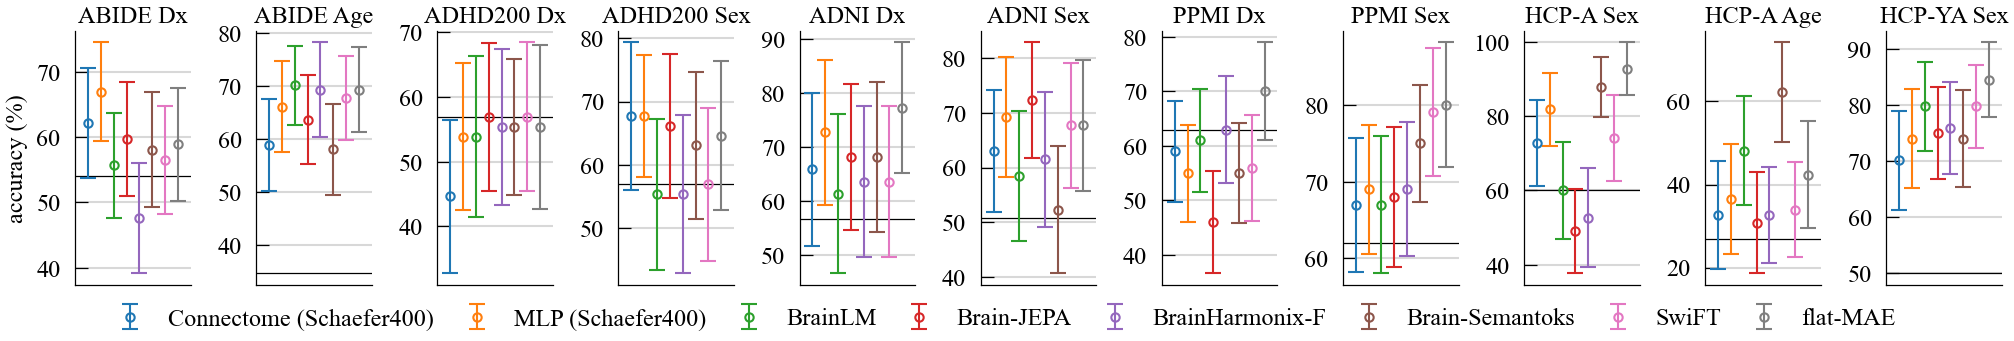

In [31]:
f = make_line_plot(summary, baseline_rows + linear_rows, datasets, chance_accs=chance_accs)
f.savefig("logistic_probe_trait.pdf")

In [13]:
attn_table = make_formatted_table(summary, baseline_rows + attn_rows, datasets)
print(attn_table.to_markdown(index=False))

| Model                    | ABIDE Dx     | ABIDE Age    | ADHD200 Dx   | ADHD200 Sex   | ADNI Dx      | ADNI Sex     | PPMI Dx      | PPMI Sex     | HCP-A Sex    | HCP-A Age    | HCP-YA Sex   |
|:-------------------------|:-------------|:-------------|:-------------|:--------------|:-------------|:-------------|:-------------|:-------------|:-------------|:-------------|:-------------|
| Connectome (Schaefer400) | 62.10 ± 4.23 | 58.87 ± 4.32 | 44.62 ± 5.94 | 67.69 ± 5.81  | 65.91 ± 7.08 | 63.08 ± 5.59 | 59.00 ± 4.60 | 67.00 ± 4.36 | 72.73 ± 5.81 | 32.69 ± 6.51 | 70.19 ± 4.42 |
| MLP (Schaefer400)        | 66.94 ± 3.76 | 66.13 ± 4.31 | 53.85 ± 5.68 | 67.69 ± 4.81  | 72.73 ± 6.73 | 69.23 ± 5.51 | 55.00 ± 4.43 | 69.00 ± 4.21 | 81.82 ± 4.96 | 36.54 ± 6.65 | 74.04 ± 4.42 |
| BrainLM                  | 47.58 ± 3.88 | 62.10 ± 4.18 | 49.23 ± 6.30 | 60.00 ± 5.69  | 63.64 ± 6.50 | 55.38 ± 5.63 | 64.00 ± 2.53 | 64.00 ± 4.73 | 70.91 ± 5.83 | 30.77 ± 5.84 | 89.42 ± 2.95 |
| Brain-JEPA             

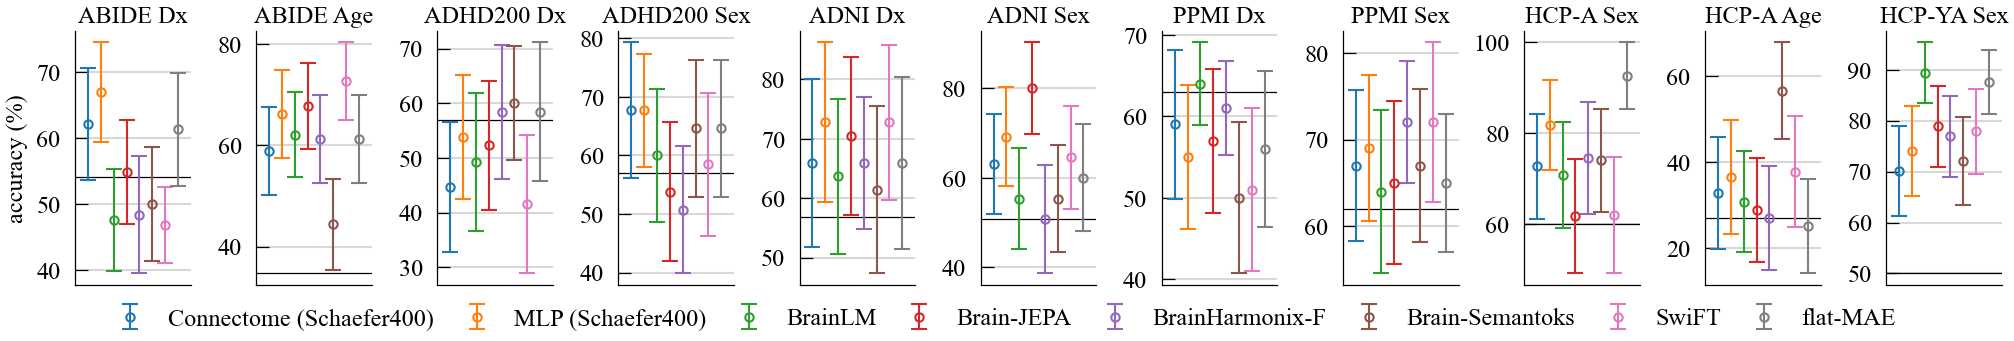

In [32]:
f = make_line_plot(summary, baseline_rows + attn_rows, datasets, chance_accs=chance_accs)
f.savefig("attn_probe_trait.pdf")

In [26]:
task_summary = summary.loc[
    :, [(col, ds) for ds in ["hcpya_task21", "nsd_cococlip"] for col in ["acc", "acc_std"]]
]
task_summary = task_summary.dropna(axis=0, how="all")

In [27]:
task_summary

acc      acc_std          acc  \
dataset                              hcpya_task21 hcpya_task21 nsd_cococlip   
model                   repr  clf                                             
brain_harmonix_f        patch attn       0.231349     0.004072          NaN   
brain_jepa_vitb_ep300   patch attn       0.112302     0.004283          NaN   
                              linear     0.159524     0.003528          NaN   
brain_semantoks         patch attn       0.903770     0.003839     0.138404   
                              linear     0.821230     0.005254          NaN   
brainlm_vitmae_111m     patch attn       0.165476     0.003710          NaN   
                              linear     0.150595     0.003228          NaN   
connectome_schaefer400  cls   linear     0.823214     0.005147     0.064564   
flat_mae_base_patch16_2 patch attn       0.989683     0.001329     0.305009   
identity_schaefer400    patch mlp        0.948016     0.003079     0.127829   
swift                   patch attn       0.198016     0.002957          NaN   

                                          acc_std  
dataset                              nsd_cococlip  
model                   repr  clf                  
brain_harmonix_f        patch attn            NaN  
brain_jepa_vitb_ep300   patch attn            NaN  
                              linear          NaN  
brain_semantoks         patch attn       0.004460  
                              linear          NaN  
brainlm_vitmae_111m     patch attn            NaN  
                              linear          NaN  
connectome_schaefer400  cls   linear     0.003296  
flat_mae_base_patch16_2 patch attn       0.005641  
identity_schaefer400    patch mlp        0.004138  
swift                   patch attn            NaN

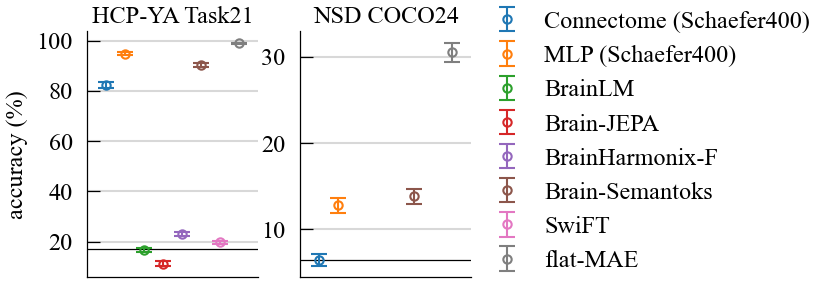

In [30]:
f = make_line_plot(
    summary,
    baseline_rows + attn_rows,
    ["hcpya_task21", "nsd_cococlip"],
    chance_accs=chance_accs,
    figsize=(2.0, 1.0),
    legend_loc="side",
)
f.savefig("attn_probe_state.pdf")